In [1]:
import torch
from torch import Tensor, nn
from math import ceil
from torch.autograd import Function
import os
from torch.autograd.function import Function
import triton
from copy import deepcopy
import triton.language as tl

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [2]:
def validate_contiguous(x: Tensor) -> Tensor:
    return x if x.is_contiguous() else x.contiguous()


In [ ]:
from torch import nn, Tensor
import torch
from torch.autograd.function import Function
import triton
import triton.language as tl
from math import ceil

import math


@triton.jit()
def _compute_sigma(x):
    return 1 / (1 + tl.exp(-x))

@triton.jit()
def _silu_op_fwd(x):
    return x * _compute_sigma(x)

@triton.jit()
def _silu_op_bwd(x, grad_output):
    sigma = _compute_sigma(x)
    act_prime = sigma * (1 + x * (1 - sigma))
    return grad_output * act_prime


In [23]:

from math import ceil
import triton
import triton.language as tl
import torch
from torch import nn, Tensor
from torch.autograd import Function

MAP_ACTIVATIONS_FWD = {"gelu": None, "silu": _silu_op_fwd}
MAP_ACTIVATIONS_BWD = {"gelu": None, "silu": _silu_op_bwd}

@triton.jit()
def _activation_fwd(x, activation_name: tl.constexpr):
    return MAP_ACTIVATIONS_FWD[activation_name](x)


@triton.jit()
def _activation_bwd(x, grad_output, activation_name: tl.constexpr):
    return MAP_ACTIVATIONS_BWD[activation_name](x, grad_output)


@triton.jit()
def _linear_act_fwd_triton(
    x_ptr,
    w_ptr,
    b_ptr,
    o_ptr,
    M,
    N,
    K,
    stride_xm,
    stride_xk,
    stride_wk,
    stride_wn,
    stride_bn,
    stride_om,
    stride_on,
    # activation_name,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    # activation_name = "silu"
    
    pid = tl.program_id(axis=0)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)

    ### map pid to (pid_m, pid_n)
    pid_m = pid // num_programs_n
    pid_n = pid % num_programs_n

    ### get offsets along M, N, K directions
    offset_m = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offset_n = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % M
    offset_k = tl.arange(0, BLOCK_SIZE_K)
    
    mask_m = offset_m[:, None] < M
    mask_n = offset_n[None, :] < N

    ### get starting pointers for x, w, b
    tile_x_ptr = x_ptr + (offset_m[:, None] * stride_xm + offset_k[None, :] * stride_xk)
    tile_w_ptr = w_ptr + (offset_k[:, None] * stride_wk + offset_n[None, :] * stride_wn)
    tile_b_ptr = b_ptr + offset_n[None, :] * stride_bn
    
    tile_b = tl.load(tile_b_ptr, mask_n, other=0.)

    ### frist compute z = x @ W.T + b
    z = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        # mask values depending on k: note that we are not loading all the row 
        # up to k * BLOCK_SIZE_K. Since we are advancing the pointers 
        # (see tile_x_ptr += ..., tile_w_ptr += ...) we are considering only
        # the portion [k*BLOCK_SIZE_K:(k+1)*BLOCK_SIZE_K].
        mask_k = offset_k < K - k * BLOCK_SIZE_K

        tile_x = tl.load(tile_x_ptr, mask_k[None, :], other=0.0)
        tile_w = tl.load(tile_w_ptr, mask_k[:, None], other=0.0)

        z = tl.dot(tile_x, tile_w, z)

        # advance the pointers along k directions to the next block
        tile_x_ptr += BLOCK_SIZE_K * stride_xk
        tile_w_ptr += BLOCK_SIZE_K * stride_wk

    ### then compute activation + downcast to bfloat16
    z += tile_b
    # o = z
    o = _silu_op_fwd(z)
    # o = o.to(tl.bfloat16)

    tile_o_ptr = o_ptr + offset_m[:, None] * stride_om + offset_n[None, :] * stride_on
    mask_o = mask_m & mask_n
    tl.store(tile_o_ptr, o, mask_o)


def _linear_act_fwd(x: Tensor, W: Tensor, b:Tensor):
    """
    Triton implementation of the following kernel
        z = x @ W.T + b
        out =  f(z)

    IMPORTANT NOTE: the .T operation is done inside tge triton kernel by swapping the
    stride values of W, therefore pass W and not W.T.

    """
    
    assert x.ndim == 2, "expected A to have ndim=2"
    assert W.ndim == 2, "expected B to have ndim=2"
    assert x.shape[1] == W.shape[0], "dimension mismatch"
    assert b.ndim <= 1, f"b is expected to be either 0D or 1D tensor, got {b.ndim}D"
    # assert b.shape[0] == W.shape[1], "dimension mismatch"

    if b.ndim == 0:
        b = b.view(1, -1)
        
    M, K = x.shape
    _, N = W.shape

    # using naive block matmul for now, implement more efficient algo later

    BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K = (64, 64, 64)  # hard-coded for now
    GROUP_SIZE_M = 8

    grid = ((ceil(M / BLOCK_SIZE_M) * ceil(N / BLOCK_SIZE_N)),)

    out = torch.zeros((M, N)).to(x.device)
    _linear_act_fwd_triton[grid](
        x,
        W,
        b,
        out,
        M,
        N,
        K,
        x.stride(0),
        x.stride(1),
        W.stride(0),
        W.stride(1),
        b.stride(0),
        out.stride(0),
        out.stride(1),
        # activation_name,
        BLOCK_SIZE_M,
        BLOCK_SIZE_N,
        BLOCK_SIZE_K,
        GROUP_SIZE_M,
    )
    ...
    
    return out


@triton.jit()
def _linear_act_bwd_triton(): ...


def _linear_act_bwd(x, W, b, grad_output): ...


class LinearActivationFunction(Function):
    def forward(ctx, x: Tensor, W: Tensor, b: Tensor):
        ctx.save_for_backward(x, W, b)
        return _linear_act_fwd(x, W, b)

    @staticmethod
    def backward(
        ctx,
        grad_output: Tensor,
    ):
        x, W, b = ctx.saved_tensors
        grad_x, grad_W, grad_b = _linear_act_bwd(x, W, b, grad_output)
        return grad_x, grad_W, grad_b


class Linear(nn.Linear):
    def __init__(self, act: str = "silu", *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.act_kind = act

    def forward(self, x: Tensor) -> Tensor:
        if x.ndim > 2:
            x = validate_contiguous(x)
            new_shape = (-1, x.shape[-1])
            return LinearActivationFunction.apply(
                x.view(new_shape),
                self.weight,
                self.bias if self.bias is not None else None,
            ).view(x.shape)
        return LinearActivationFunction.apply(
            x,
            self.weight,
            self.bias if self.bias is not None else None,
        )


32 32 32 triton fwd timing
32 32 32 torch fwd timing
288 288 288 triton fwd timing
288 288 288 torch fwd timing
544 544 544 triton fwd timing
544 544 544 torch fwd timing
800 800 800 triton fwd timing
800 800 800 torch fwd timing
1056 1056 1056 triton fwd timing
1056 1056 1056 torch fwd timing
1312 1312 1312 triton fwd timing
1312 1312 1312 torch fwd timing
1568 1568 1568 triton fwd timing
1568 1568 1568 torch fwd timing
1824 1824 1824 triton fwd timing
1824 1824 1824 torch fwd timing
2080 2080 2080 triton fwd timing
2080 2080 2080 torch fwd timing
2336 2336 2336 triton fwd timing
2336 2336 2336 torch fwd timing
2592 2592 2592 triton fwd timing
2592 2592 2592 torch fwd timing
2848 2848 2848 triton fwd timing
2848 2848 2848 torch fwd timing
3104 3104 3104 triton fwd timing
3104 3104 3104 torch fwd timing
3360 3360 3360 triton fwd timing
3360 3360 3360 torch fwd timing
3616 3616 3616 triton fwd timing
3616 3616 3616 torch fwd timing
3872 3872 3872 triton fwd timing
3872 3872 3872 torch f

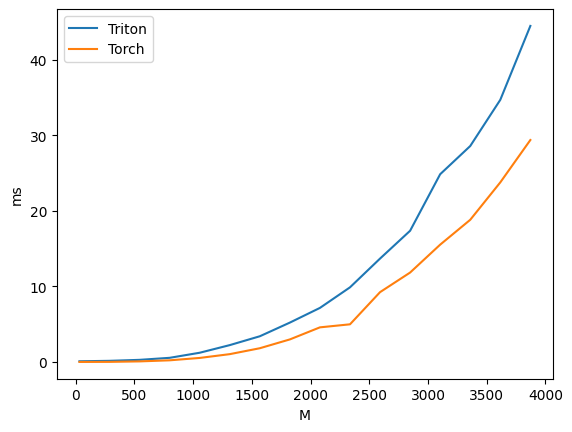

softmax - timing - fwd:
         M       N       K     Triton      Torch
0     32.0    32.0    32.0   0.107396   0.022402
1    288.0   288.0   288.0   0.166806   0.030424
2    544.0   544.0   544.0   0.297185   0.092808
3    800.0   800.0   800.0   0.564154   0.234377
4   1056.0  1056.0  1056.0   1.235595   0.549532
5   1312.0  1312.0  1312.0   2.244479   1.050328
6   1568.0  1568.0  1568.0   3.414579   1.832068
7   1824.0  1824.0  1824.0   5.222227   2.998281
8   2080.0  2080.0  2080.0   7.164434   4.593156
9   2336.0  2336.0  2336.0   9.884525   4.994924
10  2592.0  2592.0  2592.0  13.688045   9.248470
11  2848.0  2848.0  2848.0  17.365608  11.839751
12  3104.0  3104.0  3104.0  24.841120  15.529045
13  3360.0  3360.0  3360.0  28.568240  18.814566
14  3616.0  3616.0  3616.0  34.677345  23.762696
15  3872.0  3872.0  3872.0  44.447441  29.362581
32 32 32 triton fwd memory
32 32 32 torch fwd memory
288 288 288 triton fwd memory
288 288 288 torch fwd memory
544 544 544 triton fwd memory
5

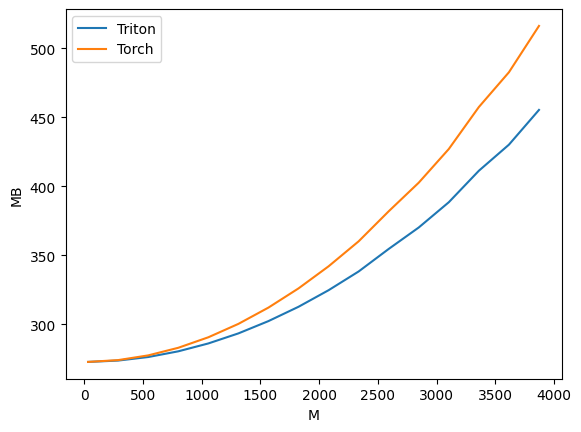

softmax - memory - fwd:
         M       N       K      Triton       Torch
0     32.0    32.0    32.0  272.852992  272.857088
1    288.0   288.0   288.0  273.837056  274.168832
2    544.0   544.0   544.0  276.393984  277.577728
3    800.0   800.0   800.0  280.523776  283.083776
4   1056.0  1056.0  1056.0  286.226432  290.686976
5   1312.0  1312.0  1312.0  293.501952  300.387328
6   1568.0  1568.0  1568.0  302.407680  312.184832
7   1824.0  1824.0  1824.0  312.771584  326.079488
8   2080.0  2080.0  2080.0  324.765696  342.071296
9   2336.0  2336.0  2336.0  338.332672  360.160256
10  2592.0  2592.0  2592.0  354.639872  381.902848
11  2848.0  2848.0  2848.0  370.185216  402.629632
12  3104.0  3104.0  3104.0  388.470784  427.010048
13  3360.0  3360.0  3360.0  411.266048  457.403392
14  3616.0  3616.0  3616.0  430.141440  482.570240
15  3872.0  3872.0  3872.0  455.308288  516.125696


In [27]:
def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

base_benchmark_kwargs = {
        "x_names":['M', 'N', "K"],  # argument names to use as an x-axis for the plot
        "x_vals":[16 * i for i in range(2, 256, 16)],  # different possible values for `x_name`
        "line_arg":'provider',  # argument name whose value corresponds to a different line in the plot
        "line_vals":['triton', 'torch'],  # possible values for `line_arg``
        "line_names":["Triton", "Torch"],  # label name for the lines
        # "styles":[('blue', '-'), ('green', '-')],  # line styles
        "ylabel":"GB/s",  # label name for the y-axis
        "plot_name":"softmax",  # name for the plot. Used also as a file name for saving the plot.
        "args":{}, #{'K': 256} # values for function arguments not in `x_names` and `y_name`
}

from copy import deepcopy
configs = []
for bench_kind in ['timing', 'memory']:
    for mode in ['fwd']: #, 'bwd']:
        _kwargs = deepcopy(base_benchmark_kwargs)
        _kwargs['args'].update({"mode" : mode})
        _kwargs['args'].update({"bench_kind" : bench_kind})
        _kwargs['ylabel'] = 'ms' if bench_kind == 'timing' else 'MB'
        _kwargs['plot_name'] += f' - {bench_kind} - {mode}'
        configs.append(triton.testing.Benchmark(**_kwargs))


def fwd(x, W, b, provider):
    if provider == "torch":
        return torch.nn.functional.silu(x @ W + b)
    elif provider == 'triton':
        return _linear_act_fwd(x, W, b)
    else:
        raise ValueError

def bwd(x, provider):
    x.requires_grad = True
    out = fwd(x, provider)
    loss = out.sum()
    loss.backward()

MAP_FWD_BKW = {
    "fwd" : fwd,
    # "bwd" : bwd,
}

def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

def benchmark_kernel():

    # for c in configs:
    #     print(c.__dict__)

    @triton.testing.perf_report(configs)
    def benchmark(M, N, K, provider, mode, bench_kind):
        
        print(M, N, K, provider, mode, bench_kind)
        
        x = torch.rand(M, K).to(DEVICE) / M / K
        W = torch.rand(K, N).to(DEVICE) / K / N
        b = torch.rand(N).to(DEVICE) / N
    
        stream = getattr(torch, DEVICE.type).Stream()
        getattr(torch, DEVICE.type).set_stream(stream)
        if bench_kind == "timing":
            ms = triton.testing.do_bench(lambda: MAP_FWD_BKW[mode](x, W, b, provider))
            # gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
            return ms #gbps(ms)
        elif bench_kind == "memory":
            mem_mb = measure_memory(MAP_FWD_BKW[mode], x, W, b, provider)
            return mem_mb
        raise ValueError(f"bench_kind must be either 'timing' or 'memory', got {bench_kind}")

    result_dfs = benchmark.run(show_plots=True, print_data=True, return_df=True)
    # for df, config in zip(result_dfs, configs):
    #     df.plot(x='N', ylabel = config.ylabel, title=config.plot_name, legend=True)

    return result_dfs

result_dfs = benchmark_kernel()

In [26]:
base_benchmark_kwargs = {
    "x_names":['N'],  # argument names to use as an x-axis for the plot
    "x_vals":[128 * i for i in range(2, 100, 10)],  # different possible values for `x_name`
    "line_arg":'provider',  # argument name whose value corresponds to a different line in the plot
    "line_vals":['triton', 'torch'],  # possible values for `line_arg``
    "line_names":["Triton", "Torch"],  # label name for the lines
    "plot_name":"softmax",  # name for the plot. Used also as a file name for saving the plot.
    "args":{'M': 4096} # values for function arguments not in `x_names` and `y_name`
}

_fwd = Softmax()

def fwd(x, provider):
    ### for benchmark olny! 
    if provider == "torch":
        return torch.nn.functional.softmax(x, dim=-1)#(x, axis=-1)
    elif provider == 'triton':
        return _fwd(x)
    else:
        raise ValueError


NameError: name 'Softmax' is not defined

In [ ]:
def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

def benchmark_kernel(fwd, base_benchmark_kwargs):
    
    def bwd(x, provider):
        x.requires_grad = True
        out = fwd(x, provider)
        loss = out.sum()
        loss.backward()


    MAP_FWD_BKW = {
        "fwd" : fwd,
        "bwd" : bwd,
    }
    
    configs = []
    for bench_kind in ['timing', 'memory']:
        for mode in ['fwd', 'bwd']:
            _kwargs = deepcopy(base_benchmark_kwargs)
            _kwargs['args'].update({"mode" : mode})
            _kwargs['args'].update({"bench_kind" : bench_kind})
            _kwargs['ylabel'] = 'ms' if bench_kind == 'timing' else 'MB'
            _kwargs['plot_name'] += f' - {bench_kind} - {mode}'
            configs.append(triton.testing.Benchmark(**_kwargs))

    @triton.testing.perf_report(configs)
    def benchmark(M, N, provider, mode, bench_kind):
        x = torch.randn(M, N, device=DEVICE, dtype=torch.bfloat16)
        stream = getattr(torch, DEVICE.type).Stream()
        getattr(torch, DEVICE.type).set_stream(stream)
        if bench_kind == "timing":
            ms = triton.testing.do_bench(lambda: MAP_FWD_BKW[mode](x, provider))
            # gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
            return ms #gbps(ms)
        elif bench_kind == "memory":
            mem_mb = measure_memory(MAP_FWD_BKW[mode], x, provider)
            return mem_mb
        raise ValueError(f"bench_kind must be either 'timing' or 'memory', got {bench_kind}")

    result_dfs = benchmark.run(show_plots=False, print_data=False, return_df=True)
    for df, config in zip(result_dfs, configs):
        df.plot(x='N', ylabel = config.ylabel, title=config.plot_name, legend=True)

    return result_dfs

benchmark_kernel(fwd, base_benchmark_kwargs)

NameError: name 'fwd' is not defined

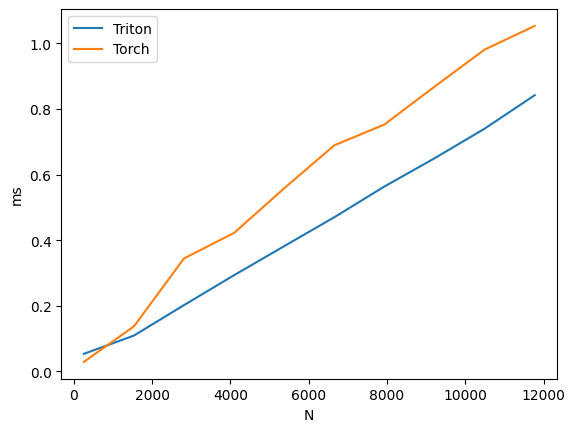

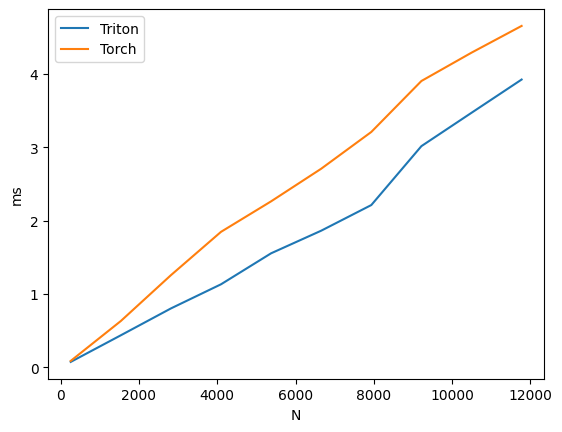

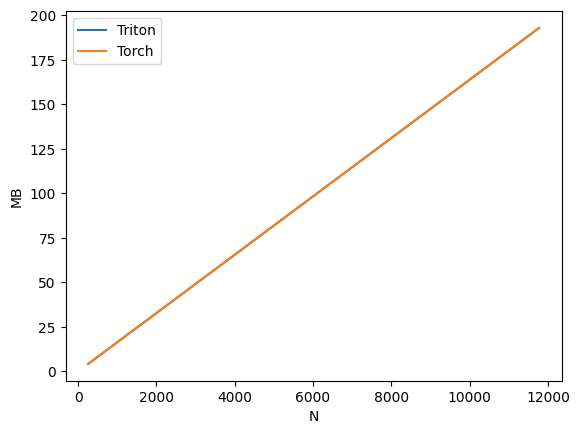

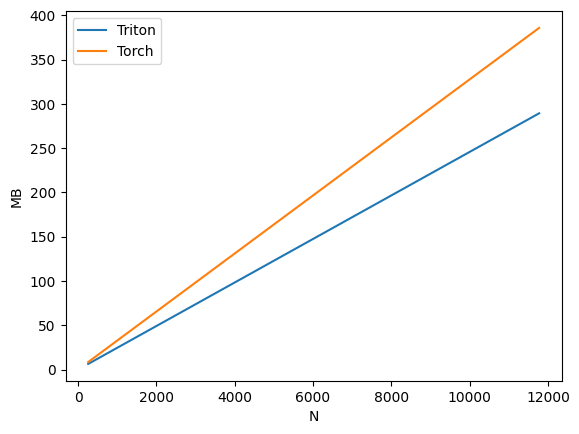